In [2]:
!pip install xgboost
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn preprocessing/modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

RANDOM_STATE = 42


Defaulting to user installation because normal site-packages is not writeable


In [3]:
file = "Exam_Score_Prediction.csv"

d = pd.read_csv(file)
print("Dataset shape:", d.shape)
d.head()


Dataset shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [5]:

print("Column names:")
print(d.columns.tolist())

print("Missing values per column:")
print(d.isna().sum())

print("Data types:")
print(d.dtypes)

print("Target summary:")
print(d["exam_score"].describe())


Column names:
['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']
Missing values per column:
student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64
Data types:
student_id            int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object
Target summary:
count    20000.000000
mean        62.513225
std         18

In [6]:
if "student_id" in d.columns:
    d = d.drop(columns=["student_id"])

T = "exam_score"
x = d.drop(columns=[T])
y = d[T]

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training rows:", xtrain.shape[0])
print("Testing rows:", xtest.shape[0])


Training rows: 16000
Testing rows: 4000


In [7]:
numeric = xtrain.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical = xtrain.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric)
print("Categorical features:", categorical)


Numeric features: ['age', 'study_hours', 'class_attendance', 'sleep_hours']
Categorical features: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [8]:
numeric_t = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_t = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_t, numeric),
        ("cat", categorical_t, categorical)
    ],
    remainder="drop"
)


In [12]:
def get_models():
    ms = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
    }
    if XGB_AVAILABLE:
        ms["XGBoost"] = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    return ms


def evaluate_model_set(xtr, xte, ytr, yte, experiment_name):
    rows = []
    fitted = {}
    for model_name, model in get_models().items():
        pipe = Pipeline(steps=[
            ("preprocessor", pre),
            ("model", model)
        ])
        pipe.fit(xtr, ytr)
        pred = pipe.predict(xte)
        rows.append({
            "Experiment": experiment_name,
            "Model": model_name,
            "MSE": mean_squared_error(yte, pred),
            "RMSE": np.sqrt(mean_squared_error(yte, pred)),
            "R2": r2_score(yte, pred)
        })
        fitted[(experiment_name, model_name)] = pipe
    return pd.DataFrame(rows), fitted

baseline_r, baseline = evaluate_model_set(
    xtrain, xtest, ytrain, ytest, "Baseline"
)
baseline_r.sort_values("R2", ascending=False)


,Experiment,Model,MSE,RMSE,R2
0,Baseline,Linear Regression,95.502096,9.772517,0.733008
2,Baseline,Gradient Boosting,97.029219,9.850341,0.728739
3,Baseline,XGBoost,97.703154,9.884491,0.726855
1,Baseline,Random Forest,105.892034,10.290386,0.703962


In [17]:
xtrainp = pre.fit_transform(xtrain)
xtestp = pre.transform(xtest)

kval = range(2, 9)
elbow = []
silhouette = []

for k in kval:
    kmean = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    ls = kmean.fit_predict(xtrainp)
    elbow.append(kmean.inertia_)
    silhouette.append(silhouette_score(xtrainp, ls))

cluster = pd.DataFrame({
    "k": list(kval),
    "inertia": elbow,
    "silhouette_score": silhouette
})
cluster


,k,inertia,silhouette_score
0,2,124386.828422,0.085094
1,3,117062.214497,0.073163
2,4,111260.058161,0.076107
3,5,106807.382435,0.073563
4,6,103603.951143,0.069009
5,7,100554.132201,0.071457
6,8,97548.956140,0.075194


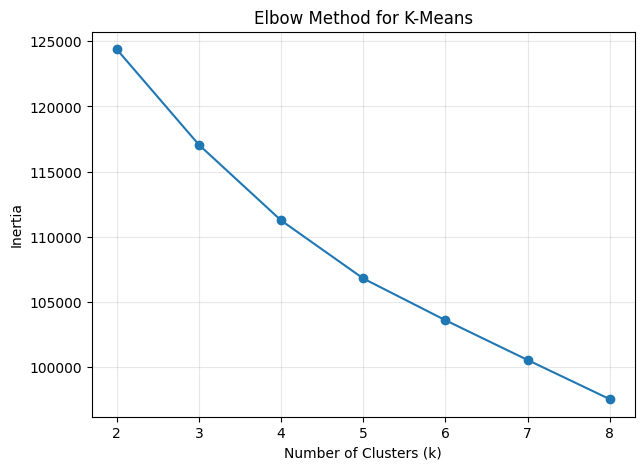

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(cluster["k"], cluster["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.show()


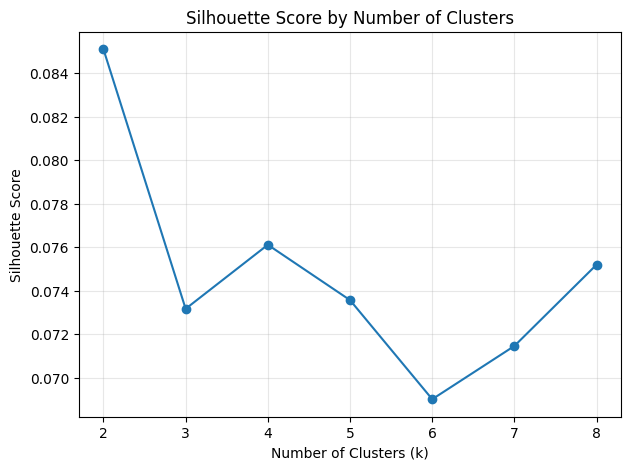

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(cluster["k"], cluster["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
bestk = int(cluster.loc[cluster["silhouette_score"].idxmax(), "k"])
print("Selected number of clusters:", bestk)

kmean = KMeans(n_clusters=bestk, random_state=RANDOM_STATE, n_init=10)
train_c = kmean.fit_predict(xtrainp)
test_c = kmean.predict(xtestp)

xtrain_h = xtrain.copy()
xtest_h = xtest.copy()

xtrain_h["student_cluster"] = train_c.astype(str)
xtest_h["student_cluster"] = test_c.astype(str)

pd.Series(train_c, name="student_cluster").value_counts().sort_index()


Selected number of clusters: 2


student_cluster
0    7913
1    8087
Name: count, dtype: int64

In [ ]:
p_c_a = PCA(n_components=2, random_state=RANDOM_STATE)
Xtrainpca = p_c_a.fit_transform(xtrainp)

pca_d = pd.DataFrame({
    "PC1": Xtrainpca[:, 0],
    "PC2": Xtrainpca[:, 1],
    "Cluster": train_c.astype(str)
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_d["Cluster"].unique()):
    subset = pca_d[pca_d["Cluster"] == cluster_id]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster_id}", alpha=0.6, s=20)
plt.title("PCA Visualization of K-Means Student Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [28]:
numeric = xtrain_h.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical = xtrain_h.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_t, numeric),
        ("cat", categorical_t, categorical)
    ],
    remainder="drop"
)

hybrid_r, hybrid_p = evaluate_model_set(
    xtrain_h, xtest_h, ytrain, ytest, "Hybrid + KMeans Cluster"
)

all_r = pd.concat([baseline_r, hybrid_r], ignore_index=True)
all_r.sort_values(["Model", "Experiment"])


,Experiment,Model,MSE,RMSE,R2
2,Baseline,Gradient Boosting,97.029219,9.850341,0.728739
6,Hybrid + KMeans Cluster,Gradient Boosting,97.029219,9.850341,0.728739
0,Baseline,Linear Regression,95.502096,9.772517,0.733008
4,Hybrid + KMeans Cluster,Linear Regression,95.499637,9.772392,0.733015
1,Baseline,Random Forest,105.892034,10.290386,0.703962
5,Hybrid + KMeans Cluster,Random Forest,106.045041,10.297817,0.703534
3,Baseline,XGBoost,97.703154,9.884491,0.726855
7,Hybrid + KMeans Cluster,XGBoost,97.293148,9.863729,0.728001


In [30]:
c = all_r.pivot(index="Model", columns="Experiment", values="R2").reset_index()
if "Hybrid + KMeans Cluster" in c.columns and "Baseline" in c.columns:
    c["R2 Improvement"] = c["Hybrid + KMeans Cluster"] - c["Baseline"]
c.sort_values("R2 Improvement", ascending=False)


Experiment,Model,Baseline,Hybrid + KMeans Cluster,R2 Improvement
3,XGBoost,0.726855,0.728001,0.001146
1,Linear Regression,0.733008,0.733015,0.000007
0,Gradient Boosting,0.728739,0.728739,0.000000
2,Random Forest,0.703962,0.703534,-0.000428


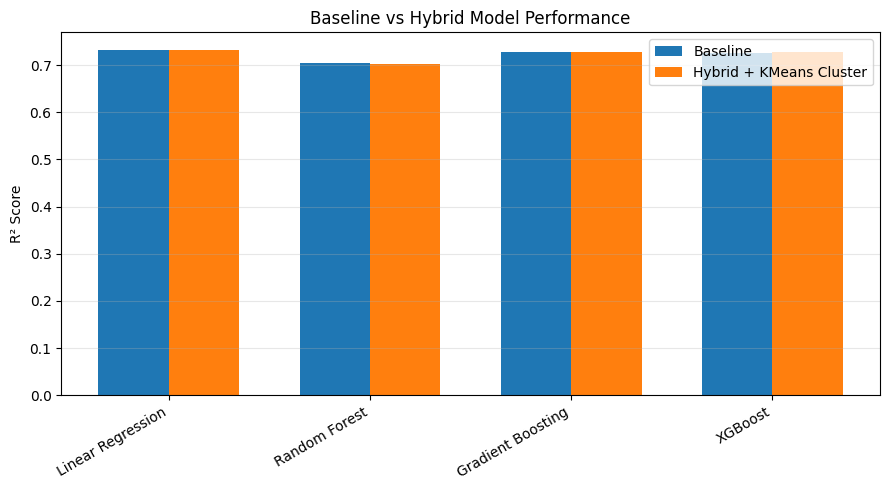

In [32]:
plt.figure(figsize=(9, 5))
plot_d = all_r.copy()
ms = plot_d["Model"].unique()
x = np.arange(len(ms))
w = 0.35

baseliner2 = [plot_d[(plot_d["Model"] == m) & (plot_d["Experiment"] == "Baseline")]["R2"].values[0] for m in ms]
hybridr2 = [plot_d[(plot_d["Model"] == m) & (plot_d["Experiment"] == "Hybrid + KMeans Cluster")]["R2"].values[0] for m in ms]

plt.bar(x - w/2, baseliner2, w, label="Baseline")
plt.bar(x + w/2, hybridr2, w, label="Hybrid + KMeans Cluster")
plt.xticks(x, ms, rotation=30, ha="right")
plt.ylabel("R² Score")
plt.title("Baseline vs Hybrid Model Performance")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
bestr = hybrid_r.sort_values("R2", ascending=False).iloc[0]
bestmn = bestr["Model"]
bestp = hybrid_p[("Hybrid + KMeans Cluster", bestmn)]

print("Best hybrid model:", bestmn)
print(bestr)

m = bestp.named_steps["model"]
pre = bestp.named_steps["preprocessor"]

if hasattr(m, "feature_importances_"):
    feature = pre.get_feature_names_out()
    importance = m.feature_importances_
    f_i = pd.DataFrame({"Feature": feature, "Importance": importance})
    f_i = f_i.sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(f_i["Feature"][::-1], f_i["Importance"][::-1])
    plt.title(f"Top Feature Importances: {bestmn}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not provide built-in feature_importances_. Try Random Forest, Gradient Boosting, or XGBoost.")


Best hybrid model: Linear Regression
Experiment    Hybrid + KMeans Cluster
Model               Linear Regression
MSE                         95.499637
RMSE                         9.772392
R2                           0.733015
Name: 0, dtype: object
The best model does not provide built-in feature_importances_. Try Random Forest, Gradient Boosting, or XGBoost.


In [ ]:
bestpred = bestp.predict(xtest_h)

plt.figure(figsize=(7, 6))
plt.scatter(ytest, bestpred, alpha=0.6)
minimum = min(ytest.min(), bestpred.min())
maximum = max(ytest.max(), bestpred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title(f"Prediction vs Actual Exam Scores: {bestmn}")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.grid(True, alpha=0.3)
plt.show()


In [40]:
final = all_r.sort_values(["Experiment", "R2"], ascending=[True, False]).copy()
final[["MSE", "RMSE", "R2"]] = final[["MSE", "RMSE", "R2"]].round(4)
final


,Experiment,Model,MSE,RMSE,R2
0,Baseline,Linear Regression,95.5021,9.7725,0.7330
2,Baseline,Gradient Boosting,97.0292,9.8503,0.7287
3,Baseline,XGBoost,97.7032,9.8845,0.7269
1,Baseline,Random Forest,105.8920,10.2904,0.7040
4,Hybrid + KMeans Cluster,Linear Regression,95.4996,9.7724,0.7330
6,Hybrid + KMeans Cluster,Gradient Boosting,97.0292,9.8503,0.7287
7,Hybrid + KMeans Cluster,XGBoost,97.2931,9.8637,0.7280
5,Hybrid + KMeans Cluster,Random Forest,106.0450,10.2978,0.7035


In [ ]:
final.to_csv("final_model_results.csv", index=False)
cluster.to_csv("kmeans_cluster_evaluation.csv", index=False)
print("Saved final_model_results.csv and kmeans_cluster_evaluation.csv")
